In [8]:
!pip install pydicom opencv-python tqdm


In [3]:
import os
import cv2
import pydicom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm


In [32]:
BASE_PATH = "/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection"
DICOM_PATH = os.path.join(BASE_PATH, "train")
CSV_PATH = os.path.join(BASE_PATH, "train.csv")

OUTPUT_IMAGE_PATH = "/kaggle/working/images"
OUTPUT_LABEL_PATH = "/kaggle/working/labels"

os.makedirs(OUTPUT_IMAGE_PATH, exist_ok=True)
os.makedirs(OUTPUT_LABEL_PATH, exist_ok=True)


In [4]:
os.listdir(BASE_PATH)  #To check the datasets in BASE_PATH


['sample_submission.csv', 'train.csv', 'test', 'train']

In [63]:
def dicom_to_png(dicom_path, output_path, limit=1000):
    files = os.listdir(dicom_path)
    count = 0
    
    for file in tqdm(files):
        if file.endswith(".dicom") or file.endswith(".dcm"):    #Convert first 1000 images to PNG format out of 15000 images
            
            if count >= limit:   # Hard stop condition
                break
            
            full_path = os.path.join(dicom_path, file)
            
            try:
                dcm = pydicom.dcmread(full_path)
                img = dcm.pixel_array
                
                # Normalize safely
                img = img - np.min(img)
                if np.max(img) != 0:
                    img = img / np.max(img)
                
                img = (img * 255).astype(np.uint8)
                
                output_file = file.replace(".dicom", ".png").replace(".dcm", ".png")
                cv2.imwrite(os.path.join(output_path, output_file), img)
                
                count += 1
            
            except Exception as e:
                print(f"Error with {file}: {e}")

    print(f"Total converted: {count}")

dicom_to_png(DICOM_PATH, OUTPUT_IMAGE_PATH, limit=1000)

  7%|▋         | 1000/15000 [18:49<4:23:27,  1.13s/it]

Total converted: 1000


Converted sample image


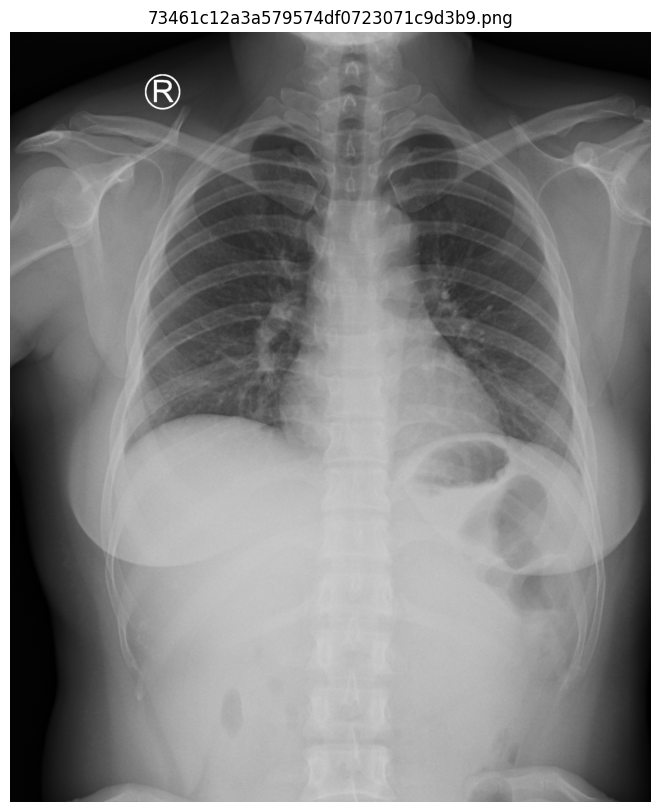

In [72]:
sample_img = os.listdir(OUTPUT_IMAGE_PATH)[0]
img = cv2.imread(os.path.join(OUTPUT_IMAGE_PATH, sample_img), 0)

plt.imshow(img, cmap='gray')
plt.rcParams["figure.figsize"] = (7, 7)
plt.title(sample_img)
plt.axis("off")
print("Converted sample image")
plt.show()


In [66]:
df = pd.read_csv(CSV_PATH)
df.head()


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN


In [67]:
classes = df['class_name'].unique()
class_dict = {name: i for i, name in enumerate(classes)}

print(class_dict)


{'No finding': 0, 'Cardiomegaly': 1, 'Aortic enlargement': 2, 'Pleural thickening': 3, 'ILD': 4, 'Nodule/Mass': 5, 'Pulmonary fibrosis': 6, 'Lung Opacity': 7, 'Atelectasis': 8, 'Other lesion': 9, 'Infiltration': 10, 'Pleural effusion': 11, 'Calcification': 12, 'Consolidation': 13, 'Pneumothorax': 14}


In [68]:
grouped = df.groupby("image_id")

for image_id, group in tqdm(grouped):
    
    img_file = os.path.join(OUTPUT_IMAGE_PATH, image_id + ".png")
    
    if not os.path.exists(img_file):
        continue
    
    img = cv2.imread(img_file)
    h, w, _ = img.shape
    
    label_file = os.path.join(OUTPUT_LABEL_PATH, image_id + ".txt")
    
    with open(label_file, "w") as f:
        for _, row in group.iterrows():
            
            # Skip No Finding (NaN boxes)
            if pd.isna(row.x_min):
                continue
            
            x_center = ((row.x_min + row.x_max) / 2) / w
            y_center = ((row.y_min + row.y_max) / 2) / h
            width = (row.x_max - row.x_min) / w
            height = (row.y_max - row.y_min) / h
            
            class_id = class_dict[row.class_name]
            
            f.write(f"{class_id} {x_center} {y_center} {width} {height}\n")


100%|██████████| 15000/15000 [01:22<00:00, 182.10it/s]


In [70]:
import os

for file in os.listdir(OUTPUT_LABEL_PATH)[:20]:
    path = os.path.join(OUTPUT_LABEL_PATH, file)
    
    if os.path.getsize(path) > 0:
        print("Found non-empty label file:", file)
        with open(path) as f:
            print(f.read())
        break


Found non-empty label file: c4d68aad9fdec87b76853d26744026bb.txt
3 0.3595920138888889 0.2390625 0.20963541666666666 0.11979166666666667
7 0.4806857638888889 0.3001736111111111 0.10894097222222222 0.14479166666666668
9 0.17664930555555555 0.4305555555555556 0.017361111111111112 0.07152777777777777
9 0.4813368055555556 0.30364583333333334 0.08940972222222222 0.134375
5 0.482421875 0.2998263888888889 0.09678819444444445 0.140625
7 0.482421875 0.2998263888888889 0.09678819444444445 0.140625
5 0.4806857638888889 0.3001736111111111 0.10894097222222222 0.14479166666666668



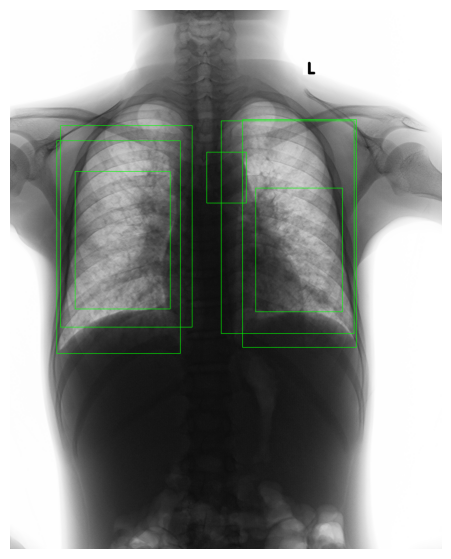

In [102]:
sample_img = os.listdir(OUTPUT_IMAGE_PATH)[27]  
img = cv2.imread(os.path.join(OUTPUT_IMAGE_PATH, sample_img))

h, w, _ = img.shape            #To check if any abnormalities found in the image the bounding box correctly displays it

label_path = os.path.join(OUTPUT_LABEL_PATH, sample_img.replace(".png", ".txt"))

if os.path.exists(label_path):
    with open(label_path) as f:
        lines = f.readlines()
        
    for line in lines:
        class_id, xc, yc, bw, bh = map(float, line.split())
        
        x1 = int((xc - bw/2) * w)
        y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w)
        y2 = int((yc + bh/2) * h)
        
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

# plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.imshow(img, cmap='gray')
plt.axis("off")
plt.rcParams["figure.figsize"] = (7, 7)
plt.show()


In [103]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# Paths
INPUT_FOLDER = OUTPUT_IMAGE_PATH          # Your converted PNG images
PROCESSED_FOLDER = "/kaggle/working/processed_images"

os.makedirs(PROCESSED_FOLDER, exist_ok=True)

TARGET_SIZE = 640

# -------- Crop Function --------
def crop_black_borders(img):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
        
    _, thresh = cv2.threshold(gray, 5, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        img = img[y:y+h, x:x+w]
        
    return img


# -------- Processing Loop --------
for image_name in tqdm(os.listdir(INPUT_FOLDER)):
    
    image_path = os.path.join(INPUT_FOLDER, image_name)
    img = cv2.imread(image_path)
    
    if img is None:
        continue
    
    # 1. Convert to Grayscale
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 2️. Crop Borders
    img = crop_black_borders(img)
    
    # 3️. Resize
    img = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE))
    
    # 4️. CLAHE (Light Contrast Enhancement)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    
    # 5️. Light Denoising (Gaussian Blur)
    img = cv2.GaussianBlur(img, (3,3), 0)
    
    # Save processed image
    save_path = os.path.join(PROCESSED_FOLDER, image_name)
    cv2.imwrite(save_path, img)

print("Preprocessing Completed Successfully!")


100%|██████████| 1000/1000 [03:56<00:00,  4.23it/s]

Preprocessing Completed Successfully!


Image shape: (640, 640)


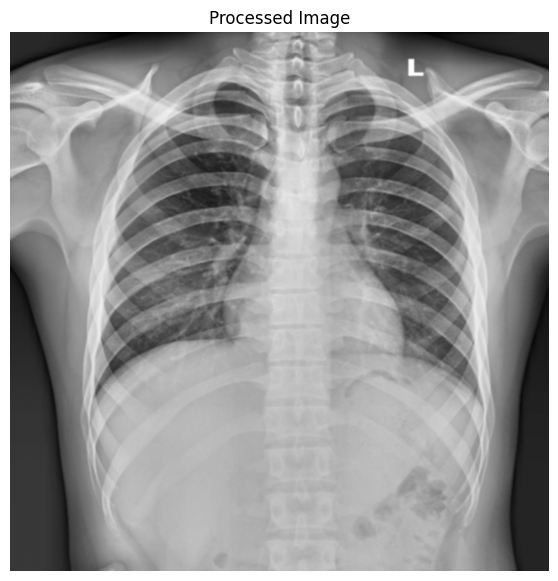

In [110]:
import matplotlib.pyplot as plt

# Pick one processed image
sample_img = os.listdir(PROCESSED_FOLDER)[5]
img_path = os.path.join(PROCESSED_FOLDER, sample_img)

img = cv2.imread(img_path, 0)

print("Image shape:", img.shape)

plt.figure(figsize=(7,7))
plt.imshow(img, cmap='gray')
plt.title("Processed Image")
plt.axis("off")
plt.show()


In [111]:
import os
import shutil
from sklearn.model_selection import train_test_split

BASE_DIR = "/kaggle/working/yolo_dataset"

os.makedirs(BASE_DIR, exist_ok=True)

for folder in ["images/train", "images/val", "images/test",
               "labels/train", "labels/val", "labels/test"]:
    os.makedirs(os.path.join(BASE_DIR, folder), exist_ok=True)


In [113]:
IMAGE_FOLDER = PROCESSED_FOLDER
LABEL_FOLDER = OUTPUT_LABEL_PATH

images = os.listdir(IMAGE_FOLDER)

train_imgs, temp_imgs = train_test_split(images, test_size=0.3, random_state=42)
val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.33, random_state=42)

print("Train:", len(train_imgs))
print("Val:", len(val_imgs))
print("Test:", len(test_imgs))


Train: 700
Val: 201
Test: 99


In [49]:
def move_files(image_list, split_type):
    for img_name in image_list:
        
        # Move image
        src_img = os.path.join(IMAGE_FOLDER, img_name)
        dst_img = os.path.join(BASE_DIR, "images", split_type, img_name)
        shutil.copy(src_img, dst_img)
        
        # Move corresponding label
        label_name = img_name.replace(".png", ".txt")
        src_label = os.path.join(LABEL_FOLDER, label_name)
        
        if os.path.exists(src_label):
            dst_label = os.path.join(BASE_DIR, "labels", split_type, label_name)
            shutil.copy(src_label, dst_label)

move_files(train_imgs, "train")
move_files(val_imgs, "val")
move_files(test_imgs, "test")

print("Dataset split completed!")


Dataset split completed!
